In [56]:
import torch
import torch.nn as nn
from modules import SAB, PMA
import numpy as np

def gen_data(batch_size, max_length=10, test=False):
    # length = np.random.randint(1, max_length + 1)
    length = 100
    x = np.random.randint(1, 100, (batch_size, length))
    y = np.max(x, axis=1)
    x, y = np.expand_dims(x, axis=2), np.expand_dims(y, axis=1)
    return x, y


class SmallDeepSet(nn.Module):
    def __init__(self, pool="max"):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(in_features=1, out_features=64),
            nn.ReLU(),
            nn.Linear(in_features=64, out_features=64),
            nn.ReLU(),
            nn.Linear(in_features=64, out_features=64),
            nn.ReLU(),
            nn.Linear(in_features=64, out_features=64),
        )
        self.dec = nn.Sequential(
            nn.Linear(in_features=64, out_features=64),
            nn.ReLU(),
            nn.Linear(in_features=64, out_features=1),
        )
        self.pool = pool

    def forward(self, x):
        x = self.enc(x)
        if self.pool == "max":
            x = x.max(dim=1)[0]
        elif self.pool == "mean":
            x = x.mean(dim=1)
        elif self.pool == "sum":
            x = x.sum(dim=1)
        x = self.dec(x)
        return x


class SmallSetTransformer(nn.Module):
    def __init__(self,):
        super().__init__()
        self.enc = nn.Sequential(
            SAB(dim_in=1, dim_out=64, num_heads=4),
            SAB(dim_in=64, dim_out=64, num_heads=4),
        )
        self.dec = nn.Sequential(
            PMA(dim=64, num_heads=4, num_seeds=1),
            nn.Linear(in_features=64, out_features=1),
        )

    def forward(self, x):
        x = self.enc(x)
        x = self.dec(x)
        return x.squeeze(-1)


class PermEqui1_max(nn.Module):
  def __init__(self, in_dim, out_dim):
    super(PermEqui1_max, self).__init__()
    self.Gamma = nn.Linear(in_dim, out_dim)

  def forward(self, x):
    xm, _ = x.max(1, keepdim=True)
    x = self.Gamma(x-xm)
    return x

class PermEqui1_mean(nn.Module):
  def __init__(self, in_dim, out_dim):
    super(PermEqui1_mean, self).__init__()
    self.Gamma = nn.Linear(in_dim, out_dim)

  def forward(self, x):
    xm = x.mean(1, keepdim=True)
    x = self.Gamma(x-xm)
    return x

class PermEqui2_max(nn.Module):
  def __init__(self, in_dim, out_dim):
    super(PermEqui2_max, self).__init__()
    self.Gamma = nn.Linear(in_dim, out_dim)
    self.Lambda = nn.Linear(in_dim, out_dim, bias=False)

  def forward(self, x):
    xm, _ = x.max(1, keepdim=True)
    xm = self.Lambda(xm)
    x = self.Gamma(x)
    x = x - xm
    return x

class PermEqui2_mean(nn.Module):
  def __init__(self, in_dim, out_dim):
    super(PermEqui2_mean, self).__init__()
    self.Gamma = nn.Linear(in_dim, out_dim)
    self.Lambda = nn.Linear(in_dim, out_dim, bias=False)

  def forward(self, x):
    xm = x.mean(1, keepdim=True)
    xm = self.Lambda(xm)
    x = self.Gamma(x)
    x = x - xm
    return x




class DTanh(nn.Module):

  def __init__(self,x_dim, d_dim, output_dim, pool = 'mean'):
    super(DTanh, self).__init__()
    self.d_dim = d_dim
    self.x_dim = x_dim
    self.output_dim = output_dim
    self.pool = pool
    if pool == 'max':
        self.phi = nn.Sequential(
          PermEqui2_max(self.x_dim, self.d_dim),
          nn.ELU(),
          PermEqui2_max(self.d_dim, self.d_dim),
          nn.ELU(),
          PermEqui2_max(self.d_dim, self.d_dim),
          nn.ELU(),
        )
    elif pool == 'max1':
        self.phi = nn.Sequential(
          PermEqui1_max(self.x_dim, self.d_dim),
          nn.ELU(),
          PermEqui1_max(self.d_dim, self.d_dim),
          nn.ELU(),
          PermEqui1_max(self.d_dim, self.d_dim),
          nn.ELU(),
        )
    elif pool == 'mean':
        self.phi = nn.Sequential(
          PermEqui2_mean(self.x_dim, self.d_dim),
          nn.ELU(),
          PermEqui2_mean(self.d_dim, self.d_dim),
          nn.ELU(),
          PermEqui2_mean(self.d_dim, self.d_dim),
          nn.ELU(),
        )
    elif pool == 'mean1':
        self.phi = nn.Sequential(
          PermEqui1_mean(self.x_dim, self.d_dim),
          nn.ELU(),
          PermEqui1_mean(self.d_dim, self.d_dim),
          nn.ELU(),
          PermEqui1_mean(self.d_dim, self.d_dim),
          nn.ELU(),
        )

    self.projection = nn.Sequential(
        
        nn.Linear(self.d_dim, self.d_dim),
        nn.ReLU(),
        nn.Linear(self.d_dim, self.d_dim),
        nn.ReLU(),
        nn.Linear(self.d_dim, self.d_dim),
        nn.ReLU(),
        nn.Linear(self.d_dim, self.output_dim),
    )

    # Optional: A global dropout to apply AFTER pooling if you need regularization
    self.global_dropout = nn.Dropout(p=0.5)
    self.smallDS = SmallDeepSet("max" if pool in ["max","max1"] else "mean")
    
  def forward(self, x):
      # 1. Equivariant context mixing: g(X)
      phi_output = self.phi(x)

      # 2. Project each element to the target dimension BEFORE pooling
      # This gives us our final g(X)_i
      projected_elements = self.projection(phi_output)
        
      # 3. Pure Model B Aggregation: Sum/Mean the contextualized elements
      if self.pool in ["max","max1"]:
          pooled_output,_ = projected_elements.max(1)
      else:
          pooled_output = projected_elements.mean(1)
    
      # pooled_output = self.smallDS(projected_elements)
      return pooled_output
      # 4. (Optional) Apply regularization to the global vector, not the elements
      # final_output = self.global_dropout(pooled_output)
      # print(self)
      # return final_output


def clip_grad(model, max_norm):
    total_norm = 0
    for p in model.parameters():
        param_norm = p.grad.data.norm(2)
        total_norm += param_norm ** 2
    total_norm = total_norm ** (0.5)
    clip_coef = max_norm / (total_norm + 1e-6)
    if clip_coef < 1:
        for p in model.parameters():
            p.grad.data.mul_(clip_coef)
    return total_norm
# DEVICE = torch.device(
#     "cuda" if torch.cuda.is_available() else
#     "mps" if torch.backends.mps.is_available() else
#     "cpu"
# )

DEVICE = torch.device(
    "cpu"
)

def train(model):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.L1Loss().to(DEVICE)
    losses = []
    for _ in range(500):
        x, y = gen_data(batch_size=2 ** 10, max_length=10)
        x, y = torch.from_numpy(x).float().to(DEVICE), torch.from_numpy(y).float().to(DEVICE)
        y_pred = model(x)
        loss = criterion(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

In [4]:
import sys
!{sys.executable} -m pip install seaborn
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
sns.set(rc={"figure.figsize": (8, 4)}, style="whitegrid")

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.3.2 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


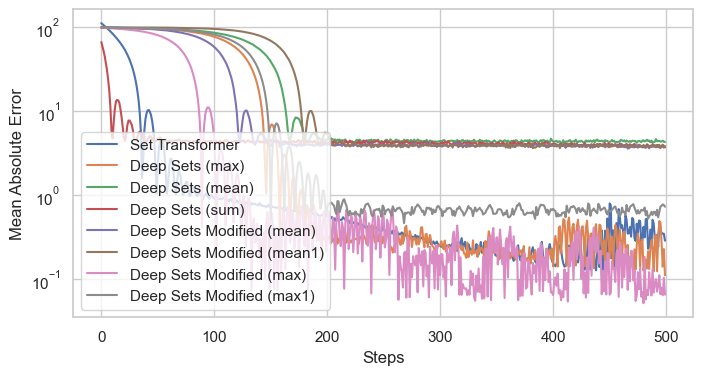

In [58]:
models = [
    ("Set Transformer", SmallSetTransformer()),
    ("Deep Sets (max)", SmallDeepSet("max")),
    ("Deep Sets (mean)", SmallDeepSet("mean")),
    ("Deep Sets (sum)", SmallDeepSet("sum")),
    ("Deep Sets Modified (mean)", DTanh(1,64,1,pool="mean")),
    ("Deep Sets Modified (mean1)", DTanh(1,64,1,pool="mean1")),
    ("Deep Sets Modified (max)", DTanh(1,64,1,pool="max")),
    ("Deep Sets Modified (max1)", DTanh(1,64,1,pool="max1")),
]

for _name, _model in models:
    _losses = train(_model)
    plt.plot(_losses, label=_name)
plt.legend()
plt.xlabel("Steps")
plt.ylabel("Mean Absolute Error")
plt.yscale("log")
plt.show()